# **E-Commerce Customer Segmentation and CRM Analytics Dashboard - Data Initiate**

---

> **The aim of this notebook:**
> - Understand dataset structure
> - Validate data quality
> - Handle missing values and invalid entries
> - Create cleaned dataset for analysis

> **Output:**
> - Understanding the form of data and the information contained within it
> - Understanding what things need to be considered for cleaning

---

## **Import Library**

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## **Loading and Checking Data**

---

### **Data Loading**

---

In [ ]:
# Load the dataset
data = pd.read_csv(r'C:\Users\user\Documents\Coding\Portofolio\E-Commerce-Customer-Segmentation-and-CRM-Analytics-Dashboard\Dataset\e_commerce_shopper.csv')
data.head()

,user_id,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,...,cart_items_average,checkout_abandonments_per_month,purchase_conversion_rate,app_usage_frequency,notification_response_rate,account_age_months,last_purchase_date,social_sharing_frequency,premium_subscription,return_rate
0,1,56,Female,Germany,Suburban,90860,Self-employed,Associate Degree,Single,0,...,10,2,62,7,74,19,2025-06-22,6,1,50
1,2,69,Male,Japan,Suburban,35423,Unemployed,Bachelor,Single,1,...,5,7,54,5,23,8,2026-07-25,3,0,37
2,3,46,Female,India,Urban,21467,Self-employed,Associate Degree,Married,1,...,3,3,33,7,12,13,2026-02-26,6,0,53
3,4,32,Male,Canada,Urban,41770,Self-employed,Bachelor,Widowed,0,...,5,9,26,4,19,9,2026-10-27,7,0,98
4,5,60,Female,Japan,Urban,183882,Employed,Associate Degree,Widowed,1,...,8,0,18,7,30,3,2026-06-23,3,0,86


**Insight:**

Data successfully loading

---

### **Check Columns and Rows**

---

In [ ]:
# Check Columns and Rows
data.shape

**Insight:**

Data containing 1000000 rows and 60 columns

---

### **Missing Value Check**

---

In [ ]:
# Check for missing values
check_data = data.isnull().sum() * 100 / len(data)
check_data

,0
user_id,0.0
age,0.0
gender,0.0
country,0.0
urban_rural,0.0
...,...
account_age_months,0.0
last_purchase_date,0.0
social_sharing_frequency,0.0
premium_subscription,0.0


**Insight:**

Of the 60 columns, no missing data was found, so imputation is unnecessary and can be used directly in the next step.

---

### **Data Duplicates Check**

---

In [ ]:
# Check for Duplicates
unique_summary = pd.DataFrame({
    'Column': data.columns,
    'Unique_count': [data[col].nunique(dropna=False) for col in data.columns],
    'Unique_percentage': [round(data[col].nunique(dropna=False) * 100 / len(data), 4) for col in data.columns]
}).sort_values(by='Unique_count', ascending=True)

unique_summary

,Column,Unique_count,Unique_percentage
9,has_children,2,0.0002
22,loyalty_program_member,2,0.0002
26,weekend_shopper,2,0.0002
34,health_conscious_shopping,2,0.0002
58,premium_subscription,2,0.0002
...,...,...,...
19,average_order_value,491,0.0491
56,last_purchase_date,731,0.0731
16,monthly_spend,5001,0.5001
5,income_level,188991,18.8991


### **Data Columns Check**

---

In [ ]:
# Column Descriptions
data.columns

Index(['user_id', 'age', 'gender', 'country', 'urban_rural', 'income_level',
 'employment_status', 'education_level', 'relationship_status',
 'has_children', 'household_size', 'occupation', 'ethnicity',
 'language_preference', 'device_type', 'weekly_purchases',
 'monthly_spend', 'cart_abandonment_rate', 'review_writing_frequency',
 'average_order_value', 'preferred_payment_method',
 'coupon_usage_frequency', 'loyalty_program_member', 'referral_count',
 'product_category_preference', 'shopping_time_of_day',
 'weekend_shopper', 'impulse_purchases_per_month', 'browse_to_buy_ratio',
 'return_frequency', 'budgeting_style', 'brand_loyalty_score',
 'impulse_buying_score', 'environmental_consciousness',
 'health_conscious_shopping', 'travel_frequency', 'hobby_count',
 'social_media_influence_score', 'reading_habits', 'exercise_frequency',
 'stress_from_financial_decisions', 'overall_stress_level',
 'sleep_quality', 'physical_activity_level', 'mental_health_score',
 'daily_session_time_minutes', 'product_views_per_day',
 'ad_views_per_day', 'ad_clicks_per_day', 'wishlist_items_count',
 'cart_items_average', 'checkout_abandonments_per_month',
 'purchase_conversion_rate', 'app_usage_frequency',
 'notification_response_rate', 'account_age_months',
 'last_purchase_date', 'social_sharing_frequency',
 'premium_subscription', 'return_rate'],
 dtype='object')

**Insight:**

> Notes:
> - Definitions are practical interpretations based on the column names and dataset context.
> - `example_value` is illustrative, not an official schema reference.

| column_name | category | definition | likely_data_type | example_value |
|---|---|---|---|---|
| `user_id` | Identity | Unique identifier for each user. | integer / string | `100001` |
| `age` | Demographics | User's age. | integer | `29` |
| `gender` | Demographics | User's gender category. | categorical | `Female` |
| `country` | Demographics | Country where the user is located or associated. | categorical | `United States` |
| `urban_rural` | Demographics | Indicates whether the user lives in an urban or rural area. | categorical | `Urban` |
| `income_level` | Demographics | User's income bracket or income category. | categorical | `High` |
| `employment_status` | Demographics | User's employment status. | categorical | `Employed` |
| `education_level` | Demographics | Highest level of education attained by the user. | categorical | `Bachelor's` |
| `relationship_status` | Demographics | User's relationship or marital status. | categorical | `Married` |
| `has_children` | Demographics | Indicates whether the user has children. | boolean / categorical | `Yes` |
| `household_size` | Demographics | Number of people in the user's household. | integer | `4` |
| `occupation` | Demographics | User's profession or job role. | categorical | `Engineer` |
| `ethnicity` | Demographics | User's ethnic background category. | categorical | `Asian` |
| `language_preference` | Demographics | Preferred language used by the user. | categorical | `English` |
| `device_type` | Technology | Main device used for shopping. | categorical | `Mobile` |
| `weekly_purchases` | Shopping Behavior | Number of purchases made per week. | integer | `3` |
| `monthly_spend` | Shopping Behavior | Total amount spent by the user per month. | float | `245.75` |
| `cart_abandonment_rate` | Shopping Behavior | Percentage or ratio of shopping carts abandoned before purchase. | float | `0.35` |
| `review_writing_frequency` | Shopping Behavior | How often the user writes product reviews. | categorical / integer | `Often` |
| `average_order_value` | Shopping Behavior | Average monetary value of each order. | float | `81.25` |
| `preferred_payment_method` | Shopping Behavior | User's most frequently used payment method. | categorical | `Credit Card` |
| `coupon_usage_frequency` | Shopping Behavior | How often the user uses coupons or discounts. | categorical | `Sometimes` |
| `loyalty_program_member` | Shopping Behavior | Indicates whether the user is enrolled in a loyalty program. | boolean / categorical | `Yes` |
| `referral_count` | Shopping Behavior | Number of referrals made by the user. | integer | `2` |
| `product_category_preference` | Shopping Behavior | Product category the user prefers most. | categorical | `Electronics` |
| `shopping_time_of_day` | Shopping Behavior | Time of day the user usually shops. | categorical | `Evening` |
| `weekend_shopper` | Shopping Behavior | Indicates whether the user tends to shop on weekends. | boolean / categorical | `Yes` |
| `impulse_purchases_per_month` | Shopping Behavior | Number of impulse purchases made per month. | integer | `5` |
| `browse_to_buy_ratio` | Shopping Behavior | Ratio between browsing activity and completed purchases. | float | `4.2` |
| `return_frequency` | Shopping Behavior | How often the user returns purchased items. | categorical / integer | `Rarely` |
| `budgeting_style` | Psychographics | User's approach to managing spending and budgeting. | categorical | `Moderate` |
| `brand_loyalty_score` | Psychographics | Score representing how loyal the user is to specific brands. | integer / float | `78` |
| `impulse_buying_score` | Psychographics | Score representing the user's tendency to buy impulsively. | integer / float | `64` |
| `environmental_consciousness` | Psychographics | Score indicating how environmentally aware the user is. | integer / float | `72` |
| `health_conscious_shopping` | Psychographics | Measure of how strongly health considerations affect shopping choices. | integer / float | `68` |
| `travel_frequency` | Lifestyle | How often the user travels. | categorical / integer | `Occasionally` |
| `hobby_count` | Lifestyle | Number of hobbies the user has. | integer | `3` |
| `social_media_influence_score` | Psychographics | Score showing how much social media influences buying behavior. | integer / float | `85` |
| `reading_habits` | Lifestyle | Measure of the user's reading behavior or reading frequency. | categorical | `Frequent` |
| `exercise_frequency` | Lifestyle | How often the user exercises. | categorical / integer | `3 times/week` |
| `stress_from_financial_decisions` | Well-being | Level of stress caused by financial or spending decisions. | integer / float | `55` |
| `overall_stress_level` | Well-being | General stress level of the user. | integer / float | `60` |
| `sleep_quality` | Well-being | Measure of the user's sleep quality. | integer / float | `7.5` |
| `physical_activity_level` | Well-being | Overall level of physical activity. | categorical / integer | `Moderate` |
| `mental_health_score` | Well-being | Score representing the user's general mental well-being. | integer / float | `74` |
| `daily_session_time_minutes` | Engagement | Average time spent per day on the platform, in minutes. | float | `42.5` |
| `product_views_per_day` | Engagement | Number of product pages viewed per day. | integer | `18` |
| `ad_views_per_day` | Engagement | Number of advertisements viewed per day. | integer | `12` |
| `ad_clicks_per_day` | Engagement | Number of advertisement clicks per day. | integer | `3` |
| `wishlist_items_count` | Engagement | Number of items saved in the wishlist. | integer | `7` |
| `cart_items_average` | Engagement | Average number of items added to the cart. | float | `2.8` |
| `checkout_abandonments_per_month` | Engagement | Number of times checkout is started but not completed in a month. | integer | `4` |
| `purchase_conversion_rate` | Engagement | Rate at which visits or views turn into completed purchases. | float | `0.12` |
| `app_usage_frequency` | Engagement | How often the user uses the shopping app. | categorical | `Daily` |
| `notification_response_rate` | Engagement | Rate at which the user responds to notifications. | float | `0.27` |
| `account_age_months` | Account | Age of the user's account in months. | integer | `18` |
| `last_purchase_date` | Account | Date of the user's most recent purchase. | date | `2025-11-14` |
| `social_sharing_frequency` | Engagement | How often the user shares products or shopping activity on social platforms. | categorical / integer | `Sometimes` |
| `premium_subscription` | Account | Indicates whether the user has a premium subscription. | boolean / categorical | `No` |
| `return_rate` | Shopping Behavior | Proportion of orders that result in returns. | float | `0.08` |

In [ ]:
# Check Data Types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 60 columns):
 #   Column                           Non-Null Count    Dtype 
---  ------                           --------------    ----- 
 0   user_id                          1000000 non-null  int64 
 1   age                              1000000 non-null  int64 
 2   gender                           1000000 non-null  object
 3   country                          1000000 non-null  object
 4   urban_rural                      1000000 non-null  object
 5   income_level                     1000000 non-null  int64 
 6   employment_status                1000000 non-null  object
 7   education_level                  1000000 non-null  object
 8   relationship_status              1000000 non-null  object
 9   has_children                     1000000 non-null  int64 
 10  household_size                   1000000 non-null  int64 
 11  occupation                       1000000 non-null  object
 12  e

## **Data Validation with Business Rules**

---

### **Separate Categorical and Numerical Data**

---

In [ ]:
# Identify column types
def identify_column_types(data):
    """
    Identifies numeric, categorical, and datetime columns.

    Parameters:
        data (pd.DataFrame | dict | list)

    Returns:
        dict
    """

    # Convert to DataFrame
    df = pd.DataFrame(data) if not isinstance(data, pd.DataFrame) else data.copy()

    # Detect column types
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    datetime_cols = df.select_dtypes(include=['datetime64[ns]', 'datetime64']).columns.tolist()

    # Categorical logic:
    # - object
    # - category
    # - boolean
    categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

    # Remove overlap (safety)
    categorical_cols = [col for col in categorical_cols if col not in numeric_cols + datetime_cols]

    # Summary
    summary = []
    for col in df.columns:
        if col in numeric_cols:
            category = "Numeric"
        elif col in datetime_cols:
            category = "Datetime"
        else:
            category = "Categorical"

        summary.append({
            "column": col,
            "data_type": str(df[col].dtype),
            "category": category,
            "null_count": df[col].isnull().sum(),
            "n_unique": df[col].nunique(dropna=True),
            "example": df[col].dropna().iloc[0] if not df[col].dropna().empty else None
        })

    summary_df = pd.DataFrame(summary)

    # Print results
    print("=" * 60)
    print(f"Total Columns   : {len(df.columns)}")
    print(f"Numeric         : {len(numeric_cols)}")
    print(f"Categorical     : {len(categorical_cols)}")
    print(f"Datetime        : {len(datetime_cols)}")
    print("=" * 60)

    print("\n📊 NUMERIC COLUMNS:")
    print(numeric_cols if numeric_cols else "None")

    print("\n🔤 CATEGORICAL COLUMNS:")
    print(categorical_cols if categorical_cols else "None")

    print("\n⏰ DATETIME COLUMNS:")
    print(datetime_cols if datetime_cols else "None")

    print("\n📋 SUMMARY:")
    print(summary_df)

    return {
        "numeric": numeric_cols,
        "categorical": categorical_cols,
        "datetime": datetime_cols,
        "summary": summary_df
    }

In [ ]:
# Identify column types
identify_column_types(data)

Total Columns   : 60
Numeric         : 45
Categorical     : 15
Datetime        : 0

📊 NUMERIC COLUMNS:
['user_id', 'age', 'income_level', 'has_children', 'household_size', 'weekly_purchases', 'monthly_spend', 'cart_abandonment_rate', 'review_writing_frequency', 'average_order_value', 'coupon_usage_frequency', 'loyalty_program_member', 'referral_count', 'weekend_shopper', 'impulse_purchases_per_month', 'browse_to_buy_ratio', 'return_frequency', 'brand_loyalty_score', 'impulse_buying_score', 'environmental_consciousness', 'health_conscious_shopping', 'travel_frequency', 'hobby_count', 'social_media_influence_score', 'reading_habits', 'exercise_frequency', 'stress_from_financial_decisions', 'overall_stress_level', 'sleep_quality', 'physical_activity_level', 'mental_health_score', 'daily_session_time_minutes', 'product_views_per_day', 'ad_views_per_day', 'ad_clicks_per_day', 'wishlist_items_count', 'cart_items_average', 'checkout_abandonments_per_month', 'purchase_conversion_rate', 'app_us

In [ ]:
# Define the function to identify column types
result = identify_column_types(data)
numeric_cols = result["numeric"]
categorical_cols = result["categorical"]

Total Columns   : 60
Numeric         : 45
Categorical     : 15
Datetime        : 0

📊 NUMERIC COLUMNS:
['user_id', 'age', 'income_level', 'has_children', 'household_size', 'weekly_purchases', 'monthly_spend', 'cart_abandonment_rate', 'review_writing_frequency', 'average_order_value', 'coupon_usage_frequency', 'loyalty_program_member', 'referral_count', 'weekend_shopper', 'impulse_purchases_per_month', 'browse_to_buy_ratio', 'return_frequency', 'brand_loyalty_score', 'impulse_buying_score', 'environmental_consciousness', 'health_conscious_shopping', 'travel_frequency', 'hobby_count', 'social_media_influence_score', 'reading_habits', 'exercise_frequency', 'stress_from_financial_decisions', 'overall_stress_level', 'sleep_quality', 'physical_activity_level', 'mental_health_score', 'daily_session_time_minutes', 'product_views_per_day', 'ad_views_per_day', 'ad_clicks_per_day', 'wishlist_items_count', 'cart_items_average', 'checkout_abandonments_per_month', 'purchase_conversion_rate', 'app_us

In [ ]:
# Display numeric data
numeric_data = data[numeric_cols]
numeric_data.head()

,user_id,age,income_level,has_children,household_size,weekly_purchases,monthly_spend,cart_abandonment_rate,review_writing_frequency,average_order_value,...,wishlist_items_count,cart_items_average,checkout_abandonments_per_month,purchase_conversion_rate,app_usage_frequency,notification_response_rate,account_age_months,social_sharing_frequency,premium_subscription,return_rate
0,1,56,90860,0,5,4,2405,0,3,445,...,5,10,2,62,7,74,19,6,1,50
1,2,69,35423,1,2,13,3651,28,6,179,...,17,5,7,54,5,23,8,3,0,37
2,3,46,21467,1,6,10,2045,14,1,26,...,18,3,3,33,7,12,13,6,0,53
3,4,32,41770,0,4,16,1611,11,2,403,...,8,5,9,26,4,19,9,7,0,98
4,5,60,183882,1,9,17,3476,57,3,68,...,10,8,0,18,7,30,3,3,0,86


In [ ]:
numeric_data.columns

Index(['user_id', 'age', 'income_level', 'has_children', 'household_size',
 'weekly_purchases', 'monthly_spend', 'cart_abandonment_rate',
 'review_writing_frequency', 'average_order_value',
 'coupon_usage_frequency', 'loyalty_program_member', 'referral_count',
 'weekend_shopper', 'impulse_purchases_per_month', 'browse_to_buy_ratio',
 'return_frequency', 'brand_loyalty_score', 'impulse_buying_score',
 'environmental_consciousness', 'health_conscious_shopping',
 'travel_frequency', 'hobby_count', 'social_media_influence_score',
 'reading_habits', 'exercise_frequency',
 'stress_from_financial_decisions', 'overall_stress_level',
 'sleep_quality', 'physical_activity_level', 'mental_health_score',
 'daily_session_time_minutes', 'product_views_per_day',
 'ad_views_per_day', 'ad_clicks_per_day', 'wishlist_items_count',
 'cart_items_average', 'checkout_abandonments_per_month',
 'purchase_conversion_rate', 'app_usage_frequency',
 'notification_response_rate', 'account_age_months',
 'social_sharing_frequency', 'premium_subscription', 'return_rate'],
 dtype='object')

In [ ]:
# Display categorical data
categorical_data = data[categorical_cols]
categorical_data.head()

,gender,country,urban_rural,employment_status,education_level,relationship_status,occupation,ethnicity,language_preference,device_type,preferred_payment_method,product_category_preference,shopping_time_of_day,budgeting_style,last_purchase_date
0,Female,Germany,Suburban,Self-employed,Associate Degree,Single,Healthcare,Other,English,Mobile,PayPal,Groceries,Morning,Strict,2025-06-22
1,Male,Japan,Suburban,Unemployed,Bachelor,Single,Finance,Other,Mandarin,Mobile,Google Pay,Groceries,Afternoon,Loose,2026-07-25
2,Female,India,Urban,Self-employed,Associate Degree,Married,Healthcare,Other,Hindi,Mobile,PayPal,Beauty,Afternoon,Moderate,2026-02-26
3,Male,Canada,Urban,Self-employed,Bachelor,Widowed,Engineering,Hispanic,Hindi,Desktop,Credit Card,Groceries,Afternoon,Moderate,2026-10-27
4,Female,Japan,Urban,Employed,Associate Degree,Widowed,Other,Asian,English,Desktop,Apple Pay,Groceries,Evening,Loose,2026-06-23


**Insight:**

Numeric and categorical data have been successfully separated

---

### **Numeric Column Validation**

---

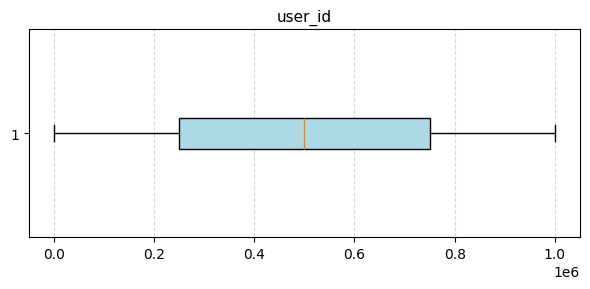

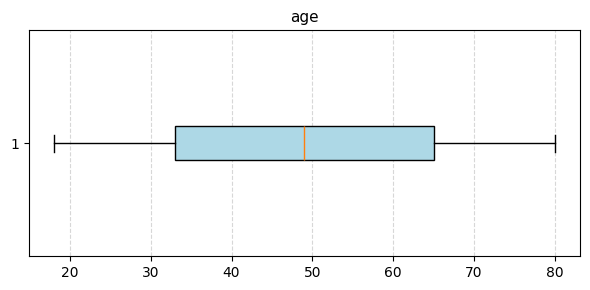

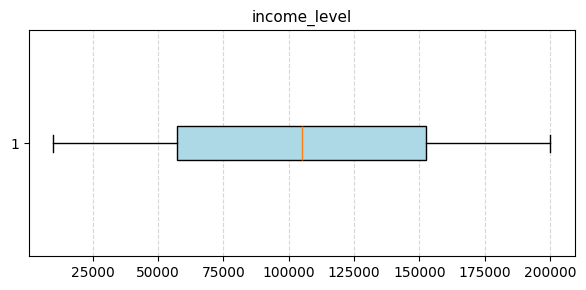

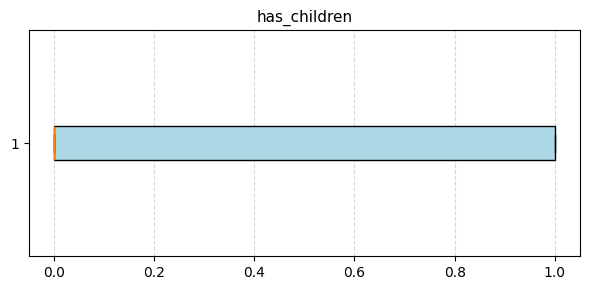

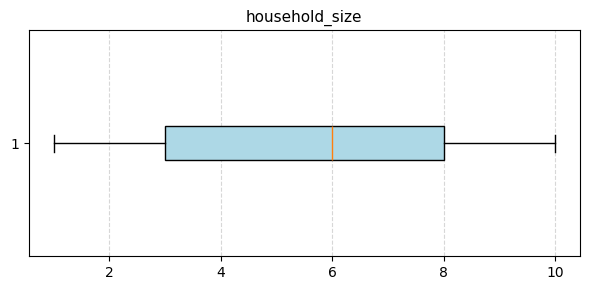

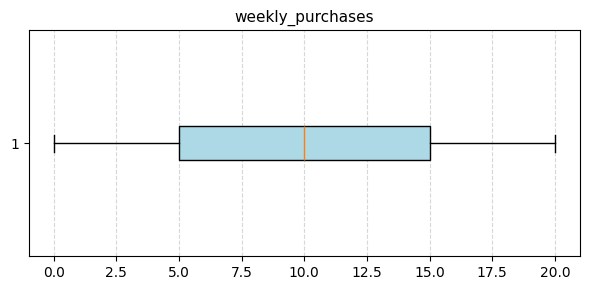

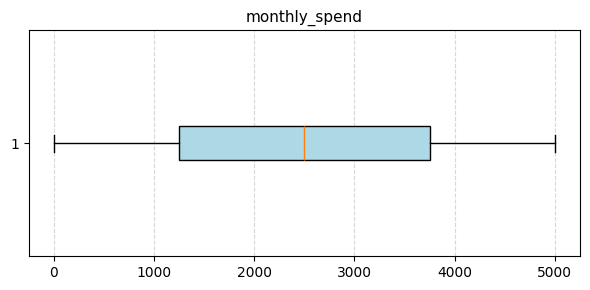

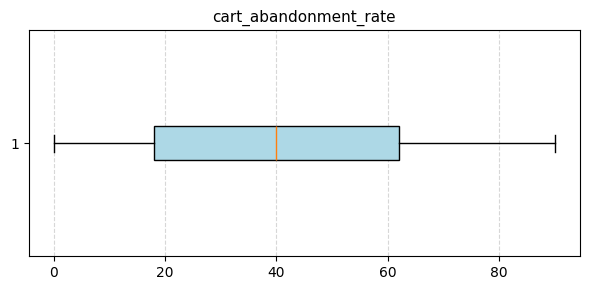

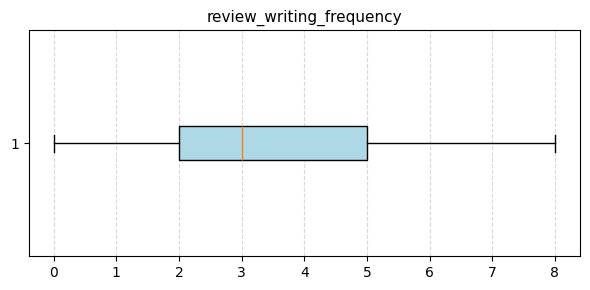

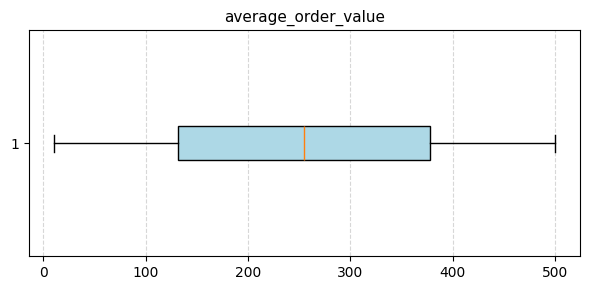

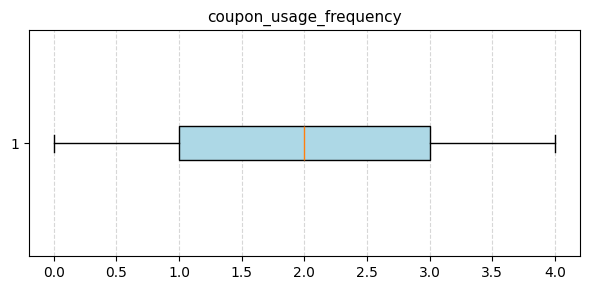

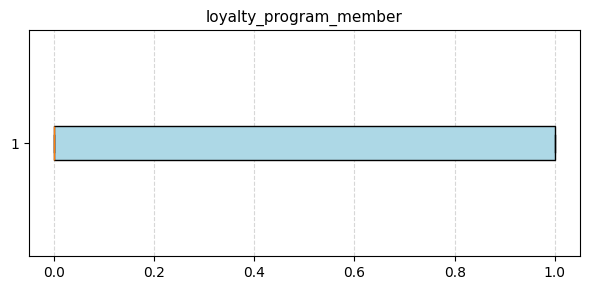

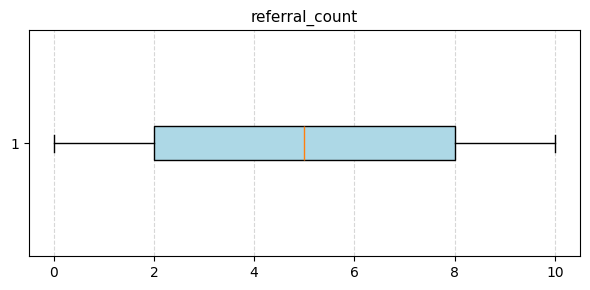

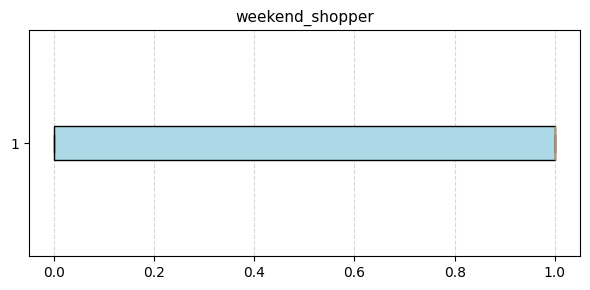

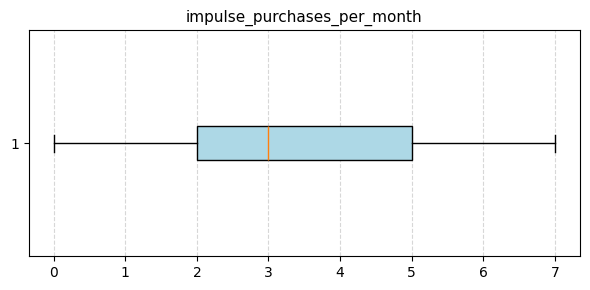

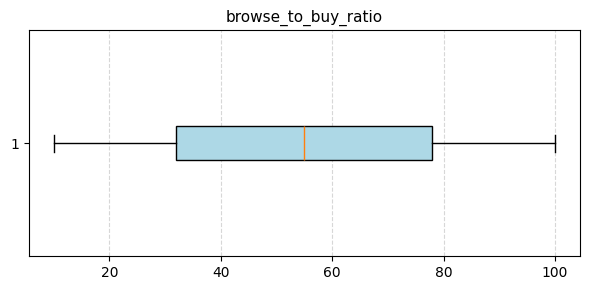

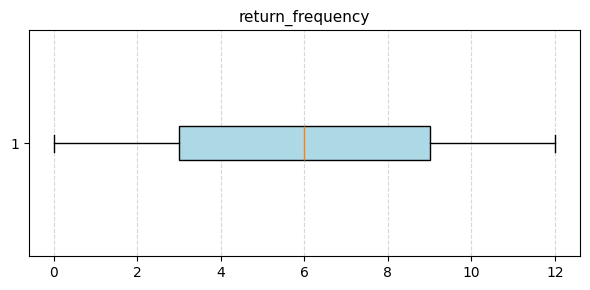

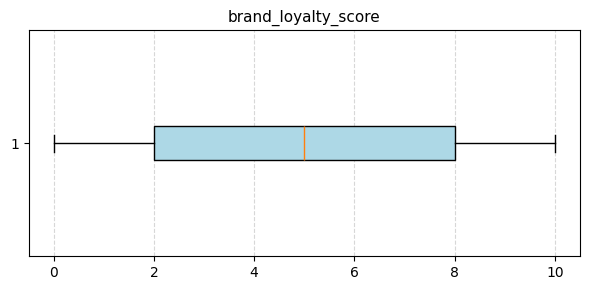

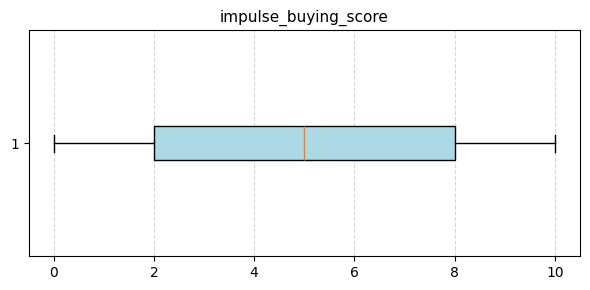

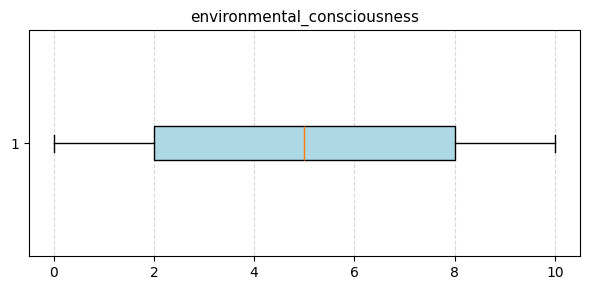

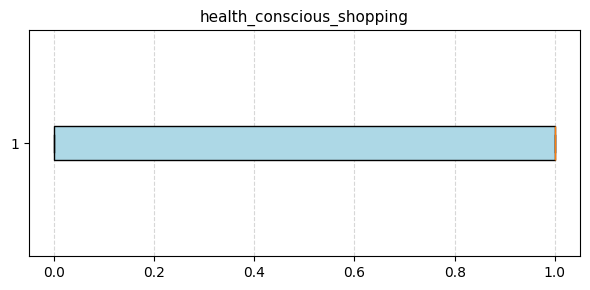

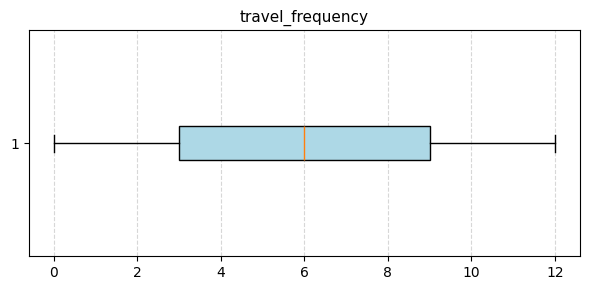

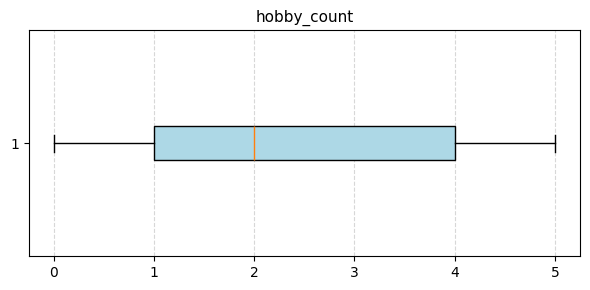

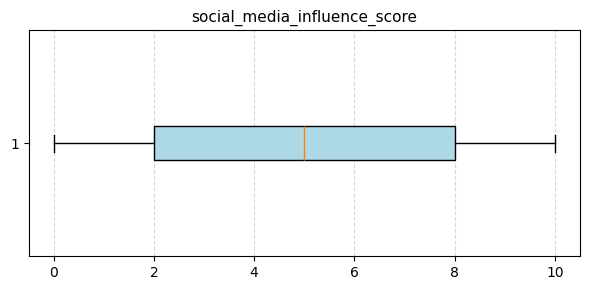

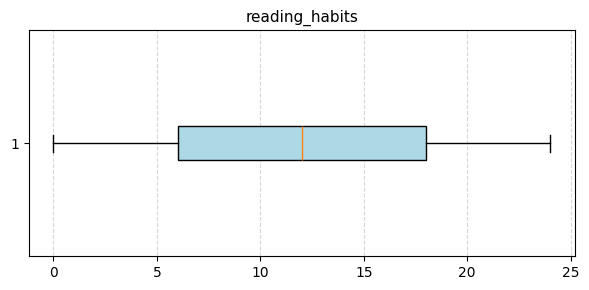

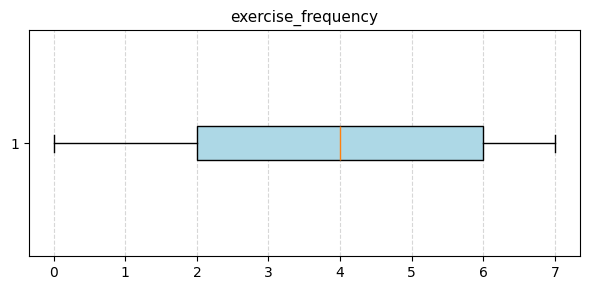

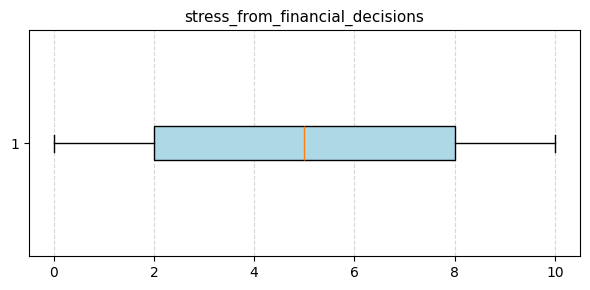

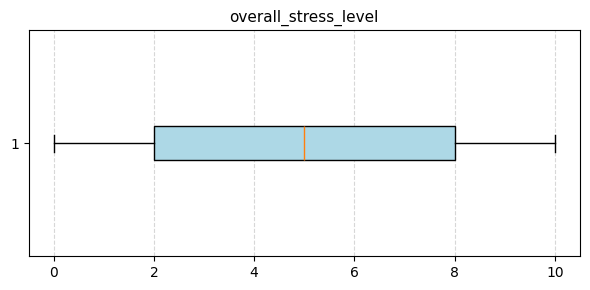

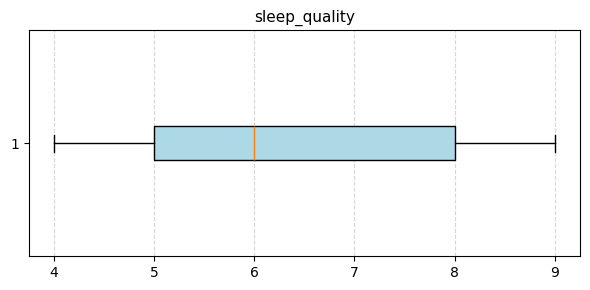

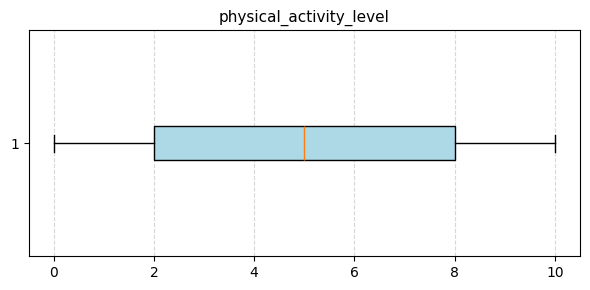

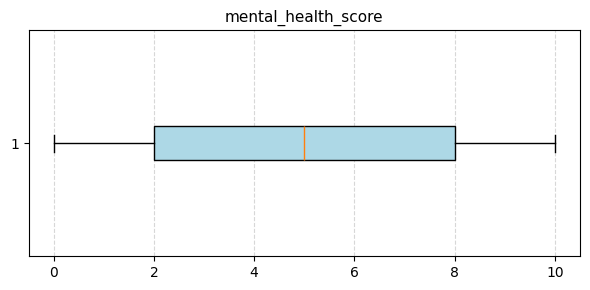

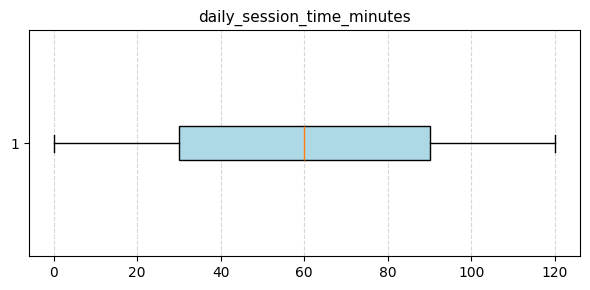

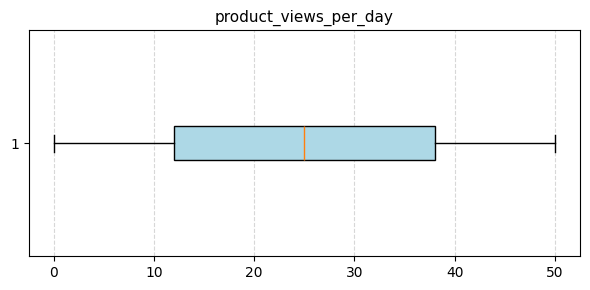

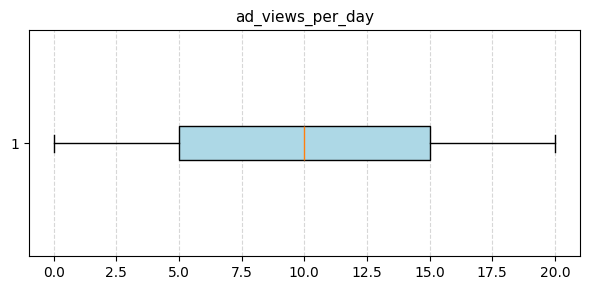

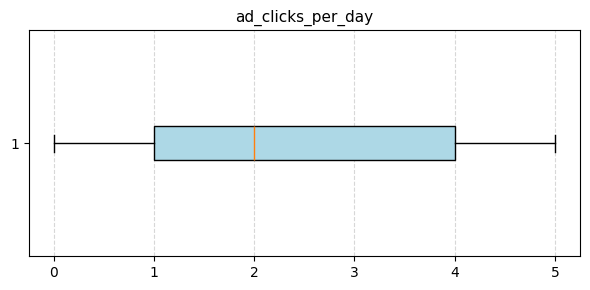

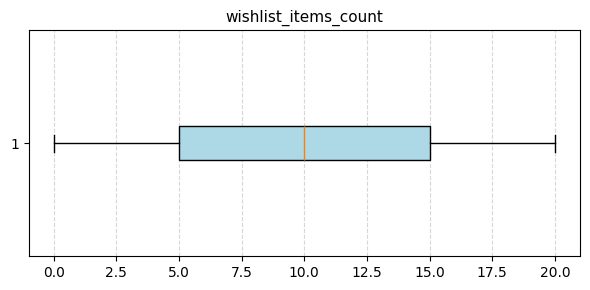

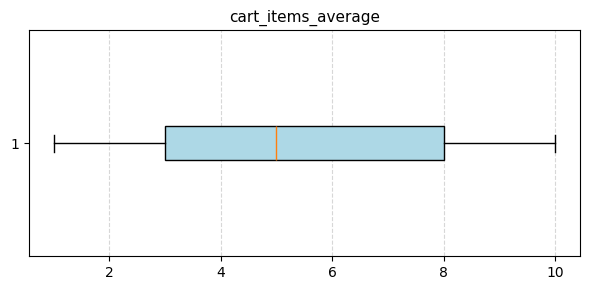

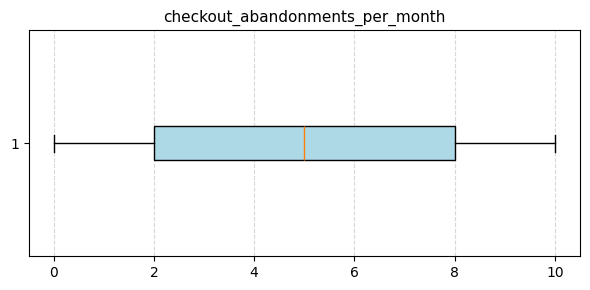

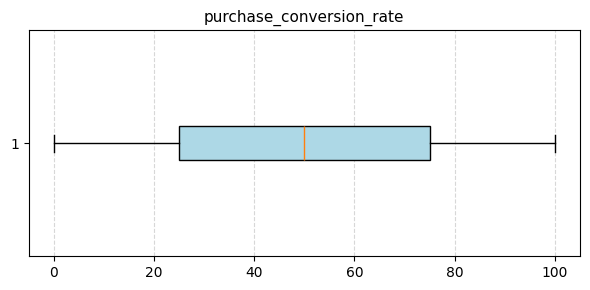

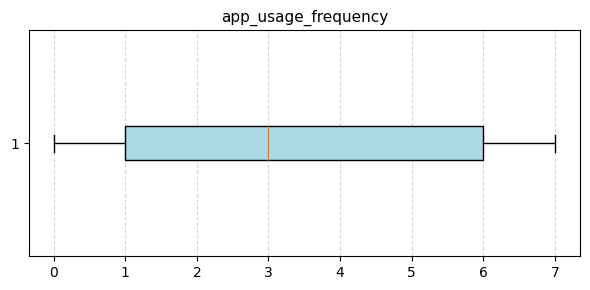

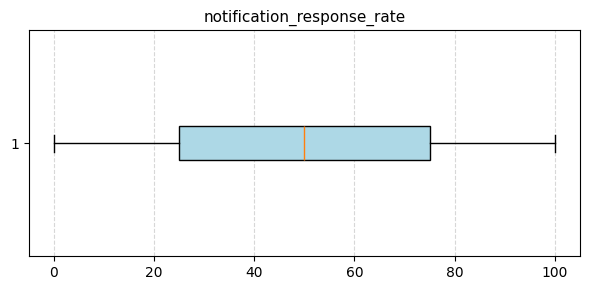

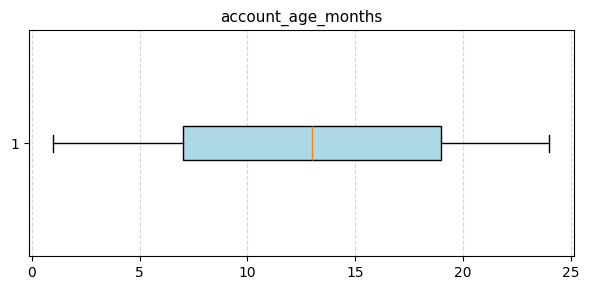

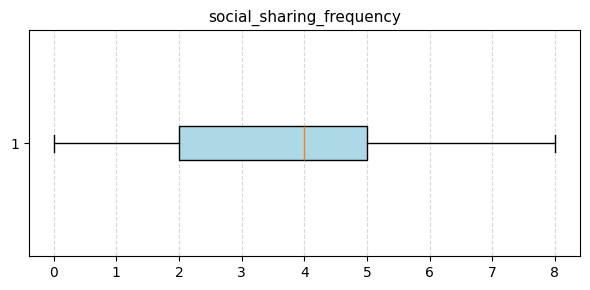

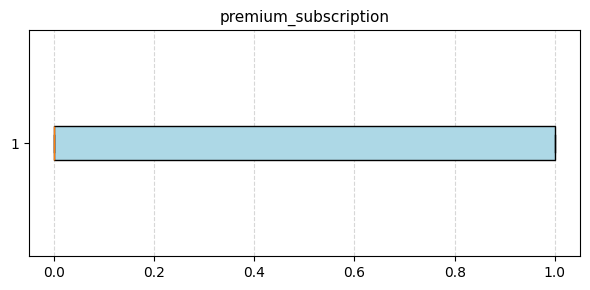

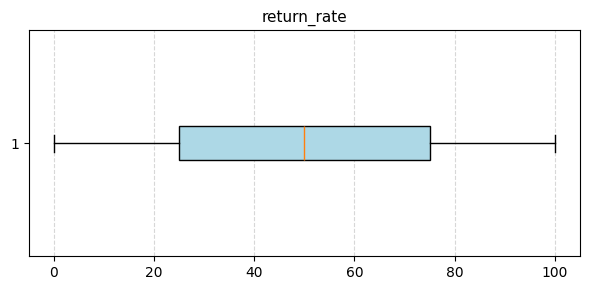

In [ ]:
# Show Boxplot for each numeric column
for col in numeric_data.columns:
    plt.figure(figsize=(6, 3))

    plt.boxplot(
        numeric_data[col].dropna(),
        vert=False,
        patch_artist=True,
        showfliers=True,  
        boxprops=dict(facecolor="lightblue"),
        flierprops=dict(marker='o', markersize=3, alpha=0.5)  
    )

    plt.title(col, fontsize=11)
    plt.grid(axis='x', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

**Insight:**

| Variable                     | Given Range | Status                | Anomaly Threshold       | Detailed Business Explanation                                                                                                                                |
| ---------------------------- | ----------- | --------------------- | ----------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| User ID                      | 0–1         | **Critical Anomaly**  | Must be unique          | User IDs cannot be binary. This indicates encoding or labeling errors. It breaks user-level tracking, impacting CRM, retention, and personalization systems. |
| Age                          | 15–80       | Normal                | <18 / >75               | Under 18 may create legal/compliance issues. Above 75 typically correlates with lower engagement. Still usable for segmentation.                             |
| Income Level                 | 10k–200k    | Normal                | Inconsistent with spend | High income with low spend or vice versa suggests behavioral mismatch or inaccurate data.                                                                    |
| Has Children                 | 0–1         | Normal                | —                       | Valid binary feature. Should be cross-validated with household size.                                                                                         |
| Household Size               | 1–10        | Minor Anomaly         | >7                      | Large households are rare in most markets; requires validation depending on region.                                                                          |
| Weekly Purchases             | 0–20        | Potential Anomaly     | >10                     | Very high frequency suggests reseller activity, bots, or non-retail behavior.                                                                                |
| Monthly Spend                | 0–5000      | Normal                | >3000                   | Extremely high spend may indicate VIP customers or potential fraud.                                                                                          |
| Cart Abandonment Rate        | 0–90%       | Normal                | >85%                    | Very high abandonment suggests UX friction, pricing issues, or trust problems.                                                                               |
| Review Writing Frequency     | 0–8         | Normal                | >5                      | Excessive reviews may indicate incentivized behavior or bot activity.                                                                                        |
| Average Order Value          | 0–500       | Normal                | >300                    | High AOV combined with high frequency suggests bulk or B2B-like behavior.                                                                                    |
| Coupon Usage Frequency       | 0–4         | Normal                | Always max              | Constant coupon usage indicates strong price sensitivity and margin risk.                                                                                    |
| Loyalty Program Member       | 0–1         | Normal                | —                       | Valid feature; should align with loyalty score and spending behavior.                                                                                        |
| Referral Count               | 0–10        | Potential Anomaly     | >5                      | High referrals may indicate referral abuse or artificial activity.                                                                                           |
| Weekend Shopper              | 0–1         | Normal                | —                       | Valid behavioral indicator.                                                                                                                                  |
| Impulse Purchases / Month    | 1–7         | Normal                | >5                      | High impulsiveness may increase revenue but also return risk.                                                                                                |
| Browse-to-Buy Ratio          | 1–100       | **High Anomaly Risk** | >50                     | Indicates excessive browsing without purchase → UX issue or bot scraping.                                                                                    |
| Return Frequency             | 1–12        | **Anomalous**         | >6                      | High return frequency suggests abuse or product dissatisfaction.                                                                                             |
| Brand Loyalty Score          | 1–10        | Normal                | Inconsistent            | High score without purchases indicates data inconsistency.                                                                                                   |
| Impulse Buying Score         | 1–10        | Normal                | Extreme (10)            | Extreme values are rare → potential survey bias.                                                                                                             |
| Environmental Consciousness  | 0–10        | Normal                | —                       | Useful for eco-product targeting.                                                                                                                            |
| Health Conscious Shopping    | 0–1         | Normal                | —                       | Valid binary segmentation feature.                                                                                                                           |
| Travel Frequency             | 0–12        | Minor Anomaly         | 12                      | Monthly travel is rare and typically tied to high-income segments.                                                                                           |
| Hobby Count                  | 0–5         | Normal                | —                       | No significant anomaly.                                                                                                                                      |
| Social Media Influence Score | 0–10        | Normal                | >8                      | High values suggest influencer potential; must align with sharing/referrals.                                                                                 |
| Reading Habits               | 0–25        | Potential Anomaly     | >20                     | Extremely high values are uncommon → possible over-reporting.                                                                                                |
| Exercise Frequency           | 0–7         | Normal                | —                       | Valid.                                                                                                                                                       |
| Financial Stress             | 0–10        | Normal                | Extreme values          | Extreme scores may indicate survey bias or noise.                                                                                                            |
| Overall Stress Level         | 0–10        | Normal                | Extreme values          | Same as above.                                                                                                                                               |
| Sleep Quality                | 4–9         | Normal                | —                       | Realistic range.                                                                                                                                             |
| Physical Activity Level      | 0–10        | Normal                | —                       | Valid.                                                                                                                                                       |
| Mental Health Score          | 0–10        | Normal                | Extreme values          | Extreme values may indicate bias.                                                                                                                            |
| Daily Session Time           | 0–120       | **Anomalous**         | >60                     | Excessive usage suggests bot activity or idle sessions.                                                                                                      |
| Product Views / Day          | 0–50        | Normal                | >40 + low time          | High views with low session time indicates automation/bot.                                                                                                   |
| Ad Views / Day               | 0–50        | Normal                | —                       | Valid.                                                                                                                                                       |
| Ad Clicks / Day              | 0–5         | Potential Anomaly     | Consistently 5          | May indicate click fraud or abnormal engagement.                                                                                                             |
| Wishlist Items               | 0–20        | Normal                | >15                     | High wishlist without purchase → low conversion intent.                                                                                                      |
| Cart Items Average           | 1–10        | Potential Anomaly     | >8                      | Indicates bulk buying behavior.                                                                                                                              |
| Checkout Abandonments        | 0–10        | Anomalous             | >7                      | Strong indicator of churn risk or checkout friction.                                                                                                         |
| Purchase Conversion Rate     | 0–100%      | **Critical Anomaly**  | >20%                    | Unrealistic. Typical e-commerce conversion is 1–5%. High values indicate tracking errors.                                                                    |
| App Usage Frequency          | 0–7         | Normal                | 0 + purchase            | Illogical if user purchases without app usage.                                                                                                               |
| Notification Response Rate   | 0–100%      | Anomalous             | >60%                    | Unrealistically high → tracking or attribution bias.                                                                                                         |
| Account Age                  | 0–25        | Normal                | <1 + high spend         | New users with high spend → fraud risk.                                                                                                                      |
| Social Sharing Frequency     | 0–8         | Normal                | High without purchase   | Influencer-like behavior without buying → inconsistency.                                                                                                     |
| Premium Subscription         | 0–1         | Normal                | —                       | Valid.                                                                                                                                                       |
| Return Rate                  | 0–100%      | **High Anomaly Risk** | >40%                    | High return rate indicates abuse, poor product fit, or expectation mismatch.                                                                                 |

For numeric data validation, nothing needs to be removed because it's still within the range despite the anomaly. This insight will be addressed during data initiation or EDA. There are several solutions for this case:

- Implementing rule-based anomaly detection

- Adding cross-feature validation logic

- Applying statistical methods (IQR, Z-score)

- Optionally, using machine learning models (Isolation Forest, clustering)

---

### **Categoric Column Validation**

---

In [ ]:
# Categorical columns list
categorical_cols_list = [
    'gender', 'country', 'urban_rural', 'employment_status',
    'education_level', 'relationship_status', 'occupation', 'ethnicity',
    'language_preference', 'device_type', 'preferred_payment_method',
    'product_category_preference', 'shopping_time_of_day',
    'budgeting_style', 'last_purchase_date'
]

# Display value counts for each categorical column
for categorical_column in categorical_cols_list:
    print(f"Value Counts for '{categorical_column}':")
    print(categorical_data[categorical_column].value_counts(dropna=False))
    print("-" * 40)

Value Counts for 'gender':
gender
Male          480132
Female        479808
Non-binary     20223
Other          19837
Name: count, dtype: int64
----------------------------------------
Value Counts for 'country':
country
Brazil       100476
Canada       100357
China        100190
Germany      100097
USA           99996
France        99992
Australia     99974
India         99899
UK            99875
Japan         99144
Name: count, dtype: int64
----------------------------------------
Value Counts for 'urban_rural':
urban_rural
Urban       500226
Suburban    299993
Rural       199781
Name: count, dtype: int64
----------------------------------------
Value Counts for 'employment_status':
employment_status
Retired          200246
Unemployed       200225
Employed         199988
Student          199949
Self-employed    199592
Name: count, dtype: int64
----------------------------------------
Value Counts for 'education_level':
education_level
Bachelor            299953
High School         29

**Insight:**

| Variable                    | Distribution Summary                        | Status         | Anomaly?           | Detailed Explanation                                                                                                                                                 |
| --------------------------- | ------------------------------------------- | -------------- | ------------------ | -------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Gender                      | Male/Female dominant, small minority groups | Valid          | No                 | Distribution is realistic. Minority categories (Non-binary, Other) are present in reasonable proportions. No issue unless region-specific bias is expected.          |
| Country                     | ~100k each country (almost equal)           | Unrealistic    | **Yes**            | Real-world data is never evenly distributed across countries. This indicates synthetic balancing or sampling bias, which reduces realism in geographic segmentation. |
| Urban/Rural                 | Urban > Suburban > Rural                    | Valid          | No                 | Matches expected real-world population distribution. No anomaly detected.                                                                                            |
| Employment Status           | All categories ~200k                        | Unrealistic    | **Yes**            | Perfectly equal distribution is not realistic. Typically, employed users dominate. Suggests artificial balancing.                                                    |
| Education Level             | Higher Bachelor & High School               | Semi-realistic | Minor              | Slightly more realistic than others, but still too clean. PhD proportion slightly high but acceptable.                                                               |
| Relationship Status         | All categories ~200k                        | Unrealistic    | **Yes**            | Real-world relationship status is not evenly distributed. Indicates synthetic data pattern.                                                                          |
| Occupation                  | All categories ~125k                        | Unrealistic    | **Yes**            | Workforce distribution is normally skewed (e.g., fewer engineers than retail workers). This uniformity is artificial.                                                |
| Ethnicity                   | Evenly distributed                          | Unrealistic    | **Yes**            | Real datasets depend on geography. Equal distribution across ethnicities suggests lack of real-world demographic dependency.                                         |
| Language Preference         | Equal across 6 languages                    | Unrealistic    | **Yes**            | Strong anomaly: language should correlate with country. This independence creates inconsistent user profiles.                                                        |
| Device Type                 | Mobile dominant, Desktop second             | Valid          | No                 | Matches industry trends. No anomaly.                                                                                                                                 |
| Preferred Payment Method    | All methods ~166k                           | Unrealistic    | **Yes**            | Payment methods are usually skewed (e.g., credit card dominance). Equal usage indicates synthetic balancing.                                                         |
| Product Category Preference | Uniform across categories                   | Unrealistic    | **Yes**            | Real users have preferences concentrated in fewer categories. Uniformity reduces personalization accuracy.                                                           |
| Shopping Time of Day        | ~25% each time slot                         | Unrealistic    | **Yes**            | Real behavior typically peaks in evening/night. Uniform distribution removes behavioral insights.                                                                    |
| Budgeting Style             | Equal split                                 | Unrealistic    | **Yes**            | “Moderate” is usually dominant. Equal split indicates artificial segmentation.                                                                                       |
| Last Purchase Date          | Uniform across ~731 days                    | Unrealistic    | **Yes (Critical)** | Real e-commerce data has spikes (weekends, promotions, holidays). Uniform distribution removes seasonality and trend analysis capability.                            |

The dataset is technically clean but structurally unrealistic. The primary concern lies not in invalid values, but in the distribution patterns and lack of relationships between variables.

- First, many categorical variables (such as country, payment method, and shopping time) exhibit nearly uniform distributions. In real-world scenarios, data is typically skewed, with certain categories dominating others. This uniformity indicates that the dataset is likely synthetic or artificially balanced, which reduces its ability to reflect actual customer behavior.

- Second, the dataset lacks natural correlations between variables. In practice, several features are inherently related. For example, language is strongly associated with country, payment methods often depend on device type, and shopping behavior varies by time of day. The absence of such relationships results in unrealistic customer profiles.

- Third, the temporal variable (last_purchase_date) shows a uniform distribution over time, with no observable spikes or seasonal trends. In a real e-commerce environment, transaction activity typically fluctuates due to weekends, promotional events, and seasonal demand patterns.

- These issues significantly limit the dataset’s usefulness for business analysis:
    - Customer segmentation may be inaccurate or misleading
    - Marketing strategies cannot be effectively optimized due to the absence of behavioral patterns
    - Machine learning models trained on this data may perform well in testing but fail in real-world applications due to unrealistic patterns

- To ensure the dataset can support meaningful and reliable insights, the following steps are required:

    1.  Introduce Realistic Distribution

        Adjust the data to reflect natural imbalances, such as higher representation from key markets, greater mobile usage, and uneven product preferences.

    2.  Establish Logical Relationships Between Variables

        Incorporate dependencies between features, for example:

        Country and language
        Device type and payment method
        Time of day and shopping activity

    3.  Enhance Temporal Realism

        Modify the time-related data to include:

        Increased activity during weekends and evenings
        Peaks during promotional periods
        Seasonal variations

    4.  Introduce Natural Variability

        Avoid overly uniform patterns by adding controlled variability or noise, making the dataset more representative of real-world conditions.

    5.  Perform Cross-Feature Validation

        Ensure that combinations of variables are logically consistent and aligned with real-world behavior.

---

### **Date Colomn Analysis**

---

In [ ]:
# Convert 'last_purchase_date' to datetime
data["last_purchase_date"] = pd.to_datetime(data["last_purchase_date"])

# ── Extract date features ──────────────────────────────────────────────────────
data["purchase_year"]  = data["last_purchase_date"].dt.year
data["purchase_month"] = data["last_purchase_date"].dt.month
data["purchase_day"]   = data["last_purchase_date"].dt.day
data["day_of_week"]    = data["last_purchase_date"].dt.day_name()  

In [ ]:
# Display the new date features
print(data.columns)

Index(['user_id', 'age', 'gender', 'country', 'urban_rural', 'income_level',
       'employment_status', 'education_level', 'relationship_status',
       'has_children', 'household_size', 'occupation', 'ethnicity',
       'language_preference', 'device_type', 'weekly_purchases',
       'monthly_spend', 'cart_abandonment_rate', 'review_writing_frequency',
       'average_order_value', 'preferred_payment_method',
       'coupon_usage_frequency', 'loyalty_program_member', 'referral_count',
       'product_category_preference', 'shopping_time_of_day',
       'weekend_shopper', 'impulse_purchases_per_month', 'browse_to_buy_ratio',
       'return_frequency', 'budgeting_style', 'brand_loyalty_score',
       'impulse_buying_score', 'environmental_consciousness',
       'health_conscious_shopping', 'travel_frequency', 'hobby_count',
       'social_media_influence_score', 'reading_habits', 'exercise_frequency',
       'stress_from_financial_decisions', 'overall_stress_level',
       'sleep_quali

**Insight:**

Successfully converted the `last_purchase_date` into several parts, such as
- purchase_year
- purchase_month
- purchase_day
- day_of_week

The purpose of this modification is for date analysis.

---

### **Initial Feature Engineering**

---

#### **Engagement Indicators**

---

In [ ]:
# Used Columns for Engagement Score
cols_es = [
    'daily_session_time_minutes',
    'product_views_per_day',
    'ad_clicks_per_day',
    'wishlist_items_count'
]

# Scaler for Engagement Score
scaler = MinMaxScaler()

scaled_df_es = pd.DataFrame(
    scaler.fit_transform(data[cols_es]),
    columns=cols_es,
    index=data.index
)

# Calculate Engagement Score
data['engagement_score'] = (
    scaled_df_es['daily_session_time_minutes'] * 0.3 +
    scaled_df_es['product_views_per_day'] * 0.2 +
    scaled_df_es['ad_clicks_per_day'] * 0.2 +
    scaled_df_es['wishlist_items_count'] * 0.3
)

NameError: name 'MinMaxScaler' is not defined

In [ ]:
# Display the new date features
print(data.columns)

Index(['user_id', 'age', 'gender', 'country', 'urban_rural', 'income_level',
       'employment_status', 'education_level', 'relationship_status',
       'has_children', 'household_size', 'occupation', 'ethnicity',
       'language_preference', 'device_type', 'weekly_purchases',
       'monthly_spend', 'cart_abandonment_rate', 'review_writing_frequency',
       'average_order_value', 'preferred_payment_method',
       'coupon_usage_frequency', 'loyalty_program_member', 'referral_count',
       'product_category_preference', 'shopping_time_of_day',
       'weekend_shopper', 'impulse_purchases_per_month', 'browse_to_buy_ratio',
       'return_frequency', 'budgeting_style', 'brand_loyalty_score',
       'impulse_buying_score', 'environmental_consciousness',
       'health_conscious_shopping', 'travel_frequency', 'hobby_count',
       'social_media_influence_score', 'reading_habits', 'exercise_frequency',
       'stress_from_financial_decisions', 'overall_stress_level',
       'sleep_quali

**Insight:**

The engagement indicator is a descriptive metric designed to summarize user activity into a single, interpretable score. It combines multiple behavioral features such as usage duration (`daily_session_time_minutes`), browsing activity (`product_views_per_day`), responsiveness to ads (`ad_clicks_per_day`), and purchase intent (`wishlist_items_count`). The goal is to reduce multidimensional behavioral data into a single value that enables easier comparison and segmentation of users.

Since each variable operates on a different scale, **Min-Max Scaling** is applied to normalize all features into a 0–1 range. Without normalization, variables with larger numerical ranges (e.g., session time) would dominate the score, leading to biased results that do not accurately reflect user behavior.

After scaling, each variable is multiplied by a weight to reflect its relative importance. In this case, session time and wishlist count are assigned higher weights (0.3) because they are stronger indicators of engagement and intent. Product views and ad clicks are given lower weights (0.2) as they are more exploratory in nature and may contain more noise.

The weights sum to 1, ensuring that the final score represents a **weighted average**, making it stable and easy to interpret. Mathematically, this approach is a **weighted linear combination**, commonly used in descriptive scoring methods.

In summary, the process consists of:

1. Normalization to align feature scales
2. Weighting to reflect feature importance
3. Aggregation into a single engagement score

This method is simple, interpretable, and suitable as a baseline in exploratory data analysis before applying more advanced modeling techniques.

---

#### **Risk Indicators**

---

In [ ]:
# Used Columns for Risk Score
cols_ri = [
    'cart_abandonment_rate',
    'return_rate',
    'purchase_conversion_rate'
]

# Scaler for Risk Score
scaled_df_ri = pd.DataFrame(
    scaler.fit_transform(data[cols_ri]),
    columns=cols_ri,
    index=data.index
)

# Calculate Risk Score
data['risk_score'] = (
    scaled_df_ri['cart_abandonment_rate'] * 0.4 +
    scaled_df_ri['return_rate'] * 0.3 +
    (1 - scaled_df_ri['purchase_conversion_rate']) * 0.3
)

Ancestor raised: An ancestor raised an exception (NameError)

In [ ]:
# Display the new date features
print(data.columns)

Index(['user_id', 'age', 'gender', 'country', 'urban_rural', 'income_level',
       'employment_status', 'education_level', 'relationship_status',
       'has_children', 'household_size', 'occupation', 'ethnicity',
       'language_preference', 'device_type', 'weekly_purchases',
       'monthly_spend', 'cart_abandonment_rate', 'review_writing_frequency',
       'average_order_value', 'preferred_payment_method',
       'coupon_usage_frequency', 'loyalty_program_member', 'referral_count',
       'product_category_preference', 'shopping_time_of_day',
       'weekend_shopper', 'impulse_purchases_per_month', 'browse_to_buy_ratio',
       'return_frequency', 'budgeting_style', 'brand_loyalty_score',
       'impulse_buying_score', 'environmental_consciousness',
       'health_conscious_shopping', 'travel_frequency', 'hobby_count',
       'social_media_influence_score', 'reading_habits', 'exercise_frequency',
       'stress_from_financial_decisions', 'overall_stress_level',
       'sleep_quali

**Insight:**

The risk indicator is a descriptive metric designed to capture the likelihood of negative user behavior, particularly related to churn or dissatisfaction. It aggregates key behavioral signals such as checkout friction (`cart_abandonment_rate`), product dissatisfaction (`return_rate`), and funnel effectiveness (`purchase_conversion_rate`) into a single score that reflects overall user risk.

Similar to engagement scoring, these variables must first be normalized using **Min-Max Scaling** to ensure they are on a comparable 0–1 scale. This step is critical because differences in value ranges can distort the contribution of each feature, leading to an unbalanced risk score.

A key distinction in risk scoring is the direction of the variables. While `cart_abandonment_rate` and `return_rate` are directly proportional to risk (higher values indicate higher risk), `purchase_conversion_rate` has an inverse relationship. To align it with the risk perspective, it is transformed using:

[
1 - \text{purchase_conversion_rate}
]

This ensures that all components consistently reflect increasing risk.

Each variable is then weighted based on its relative importance. In this formulation, `cart_abandonment_rate` is assigned the highest weight (0.4) because it directly reflects friction in the purchase process and is often a leading indicator of churn. `return_rate` and the transformed conversion rate are each assigned a weight of 0.3, as they capture dissatisfaction and inefficiency in the purchase funnel.

The weights sum to 1, producing a **weighted average** that is stable and interpretable. The final risk score is therefore a **weighted linear combination** of normalized behavioral features.

In summary, the process involves:

1. Normalizing features to ensure comparability
2. Aligning feature direction (transforming inverse relationships)
3. Applying weights to reflect importance
4. Aggregating into a single risk score

This approach provides a clear and interpretable baseline for identifying users with higher churn or behavioral risk, and it can be further refined using statistical or machine learning models.

---

## **Export Data**

---

In [ ]:
# Export DataFrame to CSV
data.to_csv("e_commerce_shopper_enhanced.csv", index=False)

## **Conclusion**

---

Data initiation or EDA has been performed on the raw data. After going through several processes, the data is ready to be used for business analysis.

---